In [ ]:
import matplotlib.pyplot as plt
import mne
import mne_connectivity
import numpy as np


In [ ]:
connectivity_methods={"plv": "Phase Locking Value (PLV)",
                      "pli": "Phase Lag Index (PLI)",
                      "wpli": "weighted Phase Lag Index (wPLI)"}

class utils:

    @staticmethod
    def plot_connectivity_matrix(info, connectivity, freq):
        method = connectivity_methods[connectivity.method]
        data = connectivity.get_data(output="dense")
        freqs = np.asarray(connectivity.freqs)
        freq_idx = np.argmin(np.abs(freq-freqs))
        ch_names = info["ch_names"]
        im = plt.imshow(data[:, :, freq_idx])
        plt.colorbar(im, label=f"{method} [a.u.]")
        plt.xticks(range(0, len(ch_names), 2), ch_names[::2], rotation=45, fontsize=8)
        plt.yticks(range(0, len(ch_names), 2), ch_names[::2], rotation=45, fontsize=8)
        plt.xlabel("Seed channels")
        plt.ylabel("Target channels")
        plt.title(f"{method} at {freq} Hz")
    
    @staticmethod
    def plot_connectivity_topo(ch, info, connectivity, freq):
        method = connectivity_methods[connectivity.method]
        freqs = np.asarray(connectivity.freqs)
        freq_idx = np.argmin(np.abs(freq-freqs))
        ch_idx = info["ch_names"].index(ch)
        data = connectivity.get_data(output="dense")
        topo = data[ch_idx, :, freq_idx] + data[:, ch_idx, freq_idx]
        mask = np.zeros(len(info["ch_names"]), dtype=bool)
        mask[ch_idx] = True
        fig, ax = plt.subplots(1,1)
        im, _ = mne.viz.plot_topomap(
            topo, pos=info, axes=ax, mask=mask, names=info["ch_names"], cmap="viridis", show=False, vlim=(topo.min(), topo.max()),
            mask_params=dict(marker='o', markerfacecolor='none', markeredgecolor='r', markersize=15))
        plt.colorbar(im, ax=ax, label=f"{method} [a.u.]")
        fig.suptitle(f"{method} for {ch} at {freq} Hz")
        plt.show()

    @staticmethod
    def plot_connectivity_per_freq(ch1, ch2, info, connectivity):
        data = connectivity.get_data(output="dense")
        method = connectivity_methods[connectivity.method]
        target_idx = info["ch_names"].index(ch1)
        seed_idx = info["ch_names"].index(ch2)
        if target_idx < seed_idx:
            target_idx, seed_idx = seed_idx, target_idx
        fig, ax = plt.subplots(1, 2, figsize=(9, 4))
        topo = np.zeros(data.shape[0])
        mask = np.zeros(len(info["ch_names"]), dtype=bool)
        ch1_idx = info["ch_names"].index(ch1)
        ch2_idx = info["ch_names"].index(ch2)
        mask[ch1_idx] = True
        mask[ch2_idx] = True
        mne.viz.plot_topomap(
            topo, pos=info, axes=ax[0], mask=mask, names=info["ch_names"], show=False,
            mask_params=dict(marker='o', markerfacecolor='none', markeredgecolor='r', markersize=15))
        ax[1].plot(connectivity.freqs, data[target_idx, seed_idx, :])
        ax[1].set(xlabel="Frequency [Hz]", ylabel=f"{method} [a.u.]", ylim=(0,1))
        fig.suptitle(f"{method} between {ch1} and {ch2}")
        plt.show()


Read simulated data and plot it.

In [ ]:
stc = mne.read_source_estimate("source")
epochs = mne.read_epochs("epochs.fif")
stc.plot(subject="fsaverage")

Look at a segment of the sensor data

In [ ]:
epochs.average().crop(0, 0.4).plot_joint(times=[0.1, 0.16, 0.23]);

## Phase Lag Value (PLV)

| Code | Description |
| --- | --- |
| `con = mne_connectivity.spectral_connectivity_epochs(epochs)` | Compute the connectivity for all `epochs` |
| `con.get_data(output="dense")` | Get the connectivity matrix with shape channels x channelsx frequencies |
| `utils.plot_connectivity_matrix(info, connectivity, freq)` | Plot the `connectivity` at frequency `freq` for the channels in `info` |
| `utils.plot_connectivity_topo(ch, info, connectivity, freq)` | Create a topoplot for the connectivity between `ch` and every other channel at the frequency `freq` |
| `utils.plot_connectivity_per_freq(ch1, ch2, info, connectivity)` | Plot the connectivity between `ch1` and `ch2` across all frequencies |

**Example**: Estimate the pariwise connectivity for all electrode pairs using the phase lag index `"plv"` method for frequencies up to `fmax=80` Hz. Then, get the connectivity matrix and print its shape - the dimensions are $(channels \times channels \times frequencies)$.

In [ ]:
plv = mne_connectivity.spectral_connectivity_epochs(epochs, method="plv", fmax=80, verbose=False)
data = plv.get_data(output="dense")
data.shape


**Exercise**: Estimate the pariwise connectivity for all electrode pairs using the phase lag index `"plv"` method for frequencies up to `fmax=40` Hz. Then, get the connectivity matrix and print its shape.

In [ ]:
plv = mne_connectivity.spectral_connectivity_epochs(epochs, method="plv", fmax=40, verbose=False)
data = plv.get_data(output="dense")
data.shape


**Example**: Plot the matrix of estimtated connectivity values at `20` Hz.

In [ ]:
freq = 20
utils.plot_connectivity_matrix(info=epochs.info, connectivity=plv, freq=freq)

**Exercise**: Plot the matrix of estimtated connectivity values at `9.3` Hz. How does this look different from the connectivity at 20 Hz?

In [ ]:
freq = 9.3
utils.plot_connectivity_matrix(info=epochs.info, connectivity=plv, freq=freq)

**Exercise**: Plot the matrix of estimtated connectivity values at `8` Hz. Would you expect there to be more or less connectivity compared to 9.3 Hz?

In [ ]:
freq = 8
utils.plot_connectivity_matrix(info=epochs.info, connectivity=plv, freq=freq)

**Example**: Plot the connectivity between `"F7"` (close to the simulates source in Broca's area) and all other electrodes at `8` Hz as a topoplot.

In [ ]:
freq = 8
ch = "F7"
utils.plot_connectivity_topo(ch=ch, info=epochs.info, connectivity=plv, freq=freq)


**Exercise**: Plot the connectivity between `"T7"` (close to the source in the primary auditory cortex) and all other electrodes at `8` Hz as a topoplot.

In [ ]:
freq = 8
ch = "T7"
utils.plot_connectivity_topo(ch=ch, info=epochs.info, connectivity=plv, freq=freq)

**Exercise**: Plot the connectivity between `"T8"` (close to the right hemisphere's primary auditory cortex) and all other electrodes at `8` Hz as a topoplot.

In [ ]:
freq = 8
ch = "T8"
utils.plot_connectivity_topo(ch, info=epochs.info, connectivity=plv, freq=freq)

**Example**: plot the connectivity between `"T7"` (Broca's area) and `"F7"` (primary auditory cortex) across all frequencies.

In [ ]:
ch1 = "T7"
ch2 = "F7"

utils.plot_connectivity_per_freq(ch1, ch2, info=epochs.info, connectivity=plv)

**Exercise**: plot the connectivity between `"T7"` (Broca's area) and its neighbor `"T9"` across frequencies. Does the high phase locking value here reflect connectivity between actual neural sources?

In [ ]:
ch1 = "T7"
ch2 = "T9"

utils.plot_connectivity_per_freq(ch1, ch2, info=epochs.info, connectivity=plv)

## Phase Lag Based Connectivity

| Code | Description |
| --- | --- |
| `mne.connectivity.spectral_connectivity_epochs(epochs, method="pli")` | Compute the spectral connectivity for all `epochs` using the phase lag index (`"pli"`) method |
| `utils.plot_connectivity_topo(ch, info, connectivity, freq)` | Create a topoplot for the connectivity between `ch` and every other channel at the frequency `freq` |

**Exercise**: Estimate the pariwise connectivity for all electrode pairs using the phase lag index `"pli"` (phase lag index) method.

In [ ]:
pli = mne_connectivity.spectral_connectivity_epochs(epochs, fmax=40, method="pli", verbose=False)

**Exercise**: Plot the connectivity between `"T7"` and all other electrodes at `8` Hz - both for PLV and PLI and compare the two topoplots.

In [ ]:
freq = 8
ch = "T7"
utils.plot_connectivity_topo(ch=ch, info=epochs.info, connectivity=plv, freq=freq)
utils.plot_connectivity_topo(ch=ch, info=epochs.info, connectivity=pli, freq=freq)

**Exercise**: plot the connectivity between `"T7"` and `"T9"` across frequencies both for PLI and PLV and compare the two plots.

In [ ]:
ch1 = "T7"
ch2 = "T9"

utils.plot_connectivity_per_freq(ch1, ch2, info=epochs.info, connectivity=plv)
utils.plot_connectivity_per_freq(ch1, ch2, info=epochs.info, connectivity=pli)

## Surface Laplacian

In [ ]:
csd = mne.preprocessing.compute_current_source_density(epochs)

In [ ]:
csd.average().crop(0, 0.4).plot_joint();

**Exercise**

In [61]:
pli_csd = mne_connectivity.spectral_connectivity_epochs(data=csd, fmax=40, method="pli", verbose=False)

/tmp/ipykernel_91012/2532890561.py:1: RuntimeWarning: There were no Annotations stored in <EpochsFIF | 97 events (all good), -1 – 2 s (baseline off), ~22.9 MiB, data loaded,
 '1': 97>, so metadata was not modified.
  pli_csd = mne_connectivity.spectral_connectivity_epochs(data=csd, fmax=40, method="pli", verbose=False)


**Exercise**

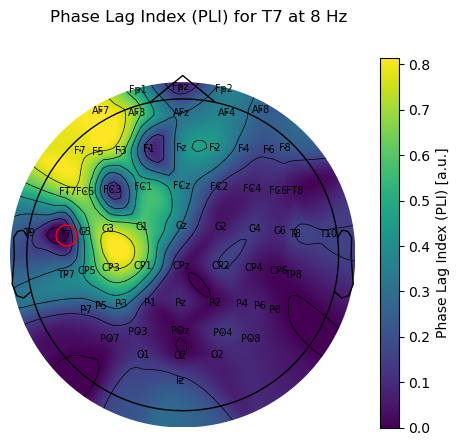

In [65]:
freq = 8
ch = "T7"
utils.plot_connectivity_topo(ch=ch, info=epochs.info, connectivity=pli_csd, freq=freq)

**Exercise**

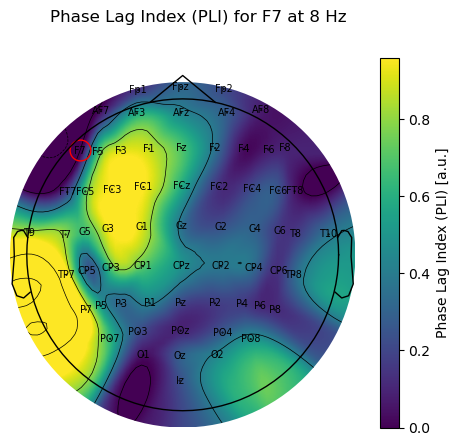

In [66]:
freq = 8
ch = "F7"
utils.plot_connectivity_topo(ch=ch, info=epochs.info, connectivity=pli_csd, freq=freq)

## Time-resolved Connectivity.